## 🧠 Step 1: Problem Framing & Theory Notes

### 1.1 What is Customer Churn? Why is churn prediction valuable?
- **Customer churn** means a customer stops using or cancels a company's service.
- Predicting churn helps Jio/Airtel identify high-risk customers early and offer retention incentives.
- **CAC (Customer Acquisition Cost)** is the cost of acquiring a new customer; **CLV (Customer Lifetime Value)** is the revenue/profit expected from a customer over the relationship.
- Retaining a valuable existing customer is often more economical than repeatedly paying CAC to replace lost customers.

### 1.2 Confusion Matrix in the churn context
- **TP:** Predicted churn and the customer actually churns.
- **TN:** Predicted no churn and the customer stays.
- **FP:** Predicted churn but the customer stays — retention budget/time may be wasted.
- **FN:** Predicted no churn but the customer actually churns — the business misses a customer who needed intervention; this is usually the more costly churn error.

### 1.3 Class Imbalance and SMOTE
- **Class imbalance** occurs when one target class is much more common than another.
- This Telco dataset is imbalanced because the majority of customers are non-churners.
- **SMOTE** creates synthetic minority-class training examples using nearby minority observations.
- SMOTE must be applied **only to the training data**, never the test set.

### 1.4 Algorithms used
- **KNN:** Classifies a customer using the labels of the nearest observations in feature space. Scaling is important because it relies on distance.
- **Gaussian Naive Bayes:** Uses Bayes' theorem and assumes features are conditionally independent with approximately Gaussian numeric distributions.
- **SVM:** Finds a decision boundary with maximum margin between classes; an RBF kernel can model nonlinear separation.
- **Decision Tree:** Recursively splits data using features that best reduce impurity. It is easy to interpret but can overfit without depth control.

### 1.5 Precision vs Recall
- Choose **Precision** when the cost of contacting a false alarm is very high and the retention team has limited capacity.
- For churn, **Recall is usually more important** because missing a real churner (False Negative) can mean losing their future CLV.
- In a capacity-constrained campaign, both matter: high Recall finds more churners, while Precision ensures calls are focused on customers most likely to leave.

## 📂 Step 2: Dataset Loading & Exploratory Data Analysis

### 2.1 Load & Inspect

In [1]:
import warnings, time, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from imblearn.over_sampling import SMOTE
import joblib

pd.set_option("display.max_columns", 100)
sns.set_context("notebook")
RANDOM_STATE = 42

In [3]:
candidates = [
    "dataset.csv",
    "dataset.csv"
]

data_path = next((p for p in candidates if os.path.exists(p)), None)
if data_path is None:
    raise FileNotFoundError(
        "Dataset not found. Put dataset(7).csv or WA_Fn-UseC_-Telco-Customer-Churn.csv "
        "in the same folder as this notebook."
    )

df = pd.read_csv(data_path)
print("Loaded:", data_path)
print("Shape:", df.shape)
display(df.head(10))

Loaded: dataset.csv
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [4]:
print("DATAFRAME INFO")
df.info()

print("\nDESCRIPTIVE STATISTICS")
display(df.describe(include="all").T)

DATAFRAME INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
blank_totalcharges = df["TotalCharges"].astype(str).str.strip().eq("").sum()
print("Whitespace/blank TotalCharges rows:", blank_totalcharges)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing TotalCharges after conversion:", df["TotalCharges"].isna().sum())

df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())
print("TotalCharges dtype:", df["TotalCharges"].dtype)

Whitespace/blank TotalCharges rows: 11
Missing TotalCharges after conversion: 11
TotalCharges dtype: float64


In [6]:
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True).mul(100).round(2)

print("Class counts:")
display(churn_counts.to_frame("Count"))
print("Class percentages:")
display(churn_pct.to_frame("Percentage"))

print(f"Churned customers: {churn_pct.get('Yes', np.nan):.2f}%")
print("Conclusion: The target is moderately imbalanced (No is the majority class).")

Class counts:


,Count
Churn,
No,5174
Yes,1869


Class percentages:


,Percentage
Churn,
No,73.46
Yes,26.54


Churned customers: 26.54%
Conclusion: The target is moderately imbalanced (No is the majority class).


### 2.2 Univariate Analysis

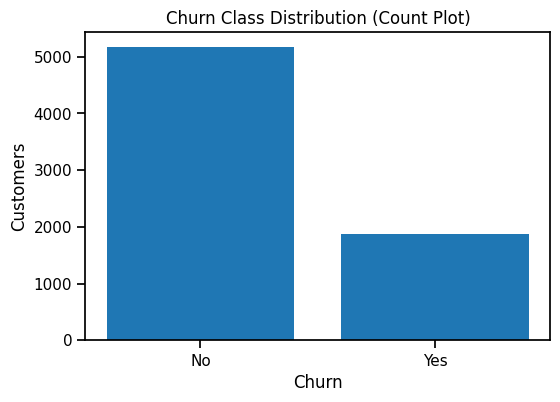

In [7]:
churn_plot = df["Churn"].value_counts().reindex(["No", "Yes"])
plt.figure(figsize=(6,4))
plt.bar(churn_plot.index, churn_plot.values)
plt.title("Churn Class Distribution (Count Plot)")
plt.xlabel("Churn")
plt.ylabel("Customers")
plt.show()

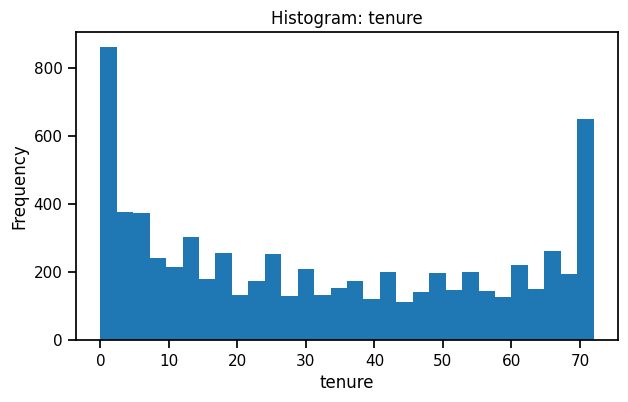

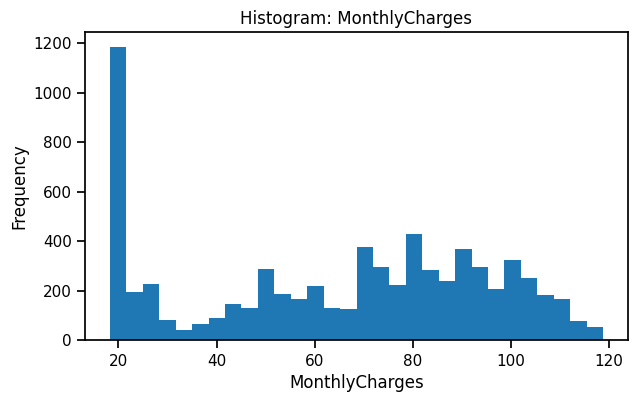

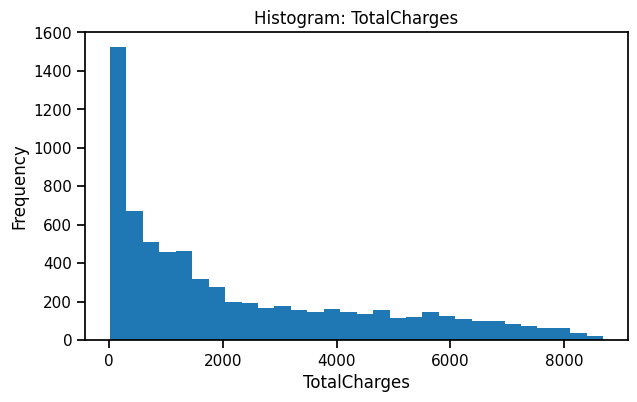

In [8]:
for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    plt.figure(figsize=(7,4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

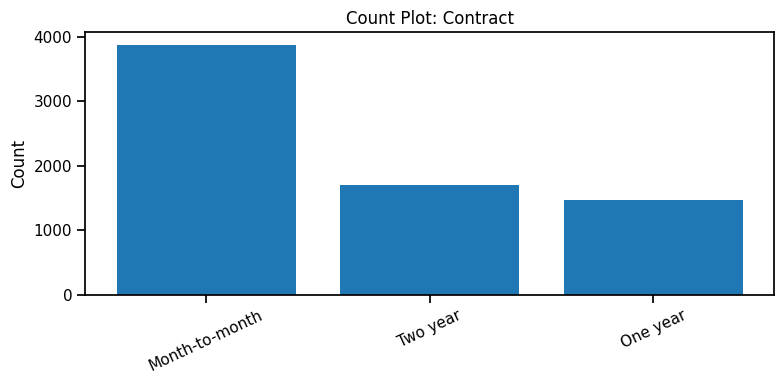

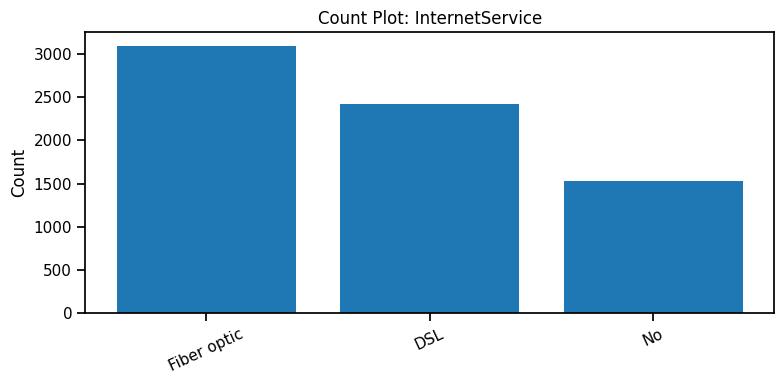

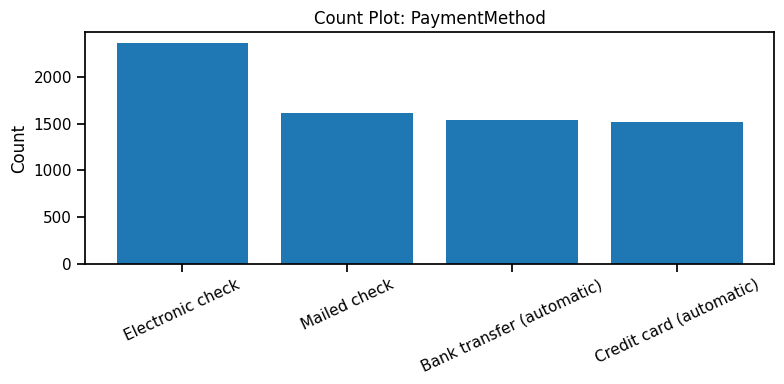

In [9]:
for col in ["Contract", "InternetService", "PaymentMethod"]:
    counts = df[col].value_counts()
    plt.figure(figsize=(8,4))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f"Count Plot: {col}")
    plt.ylabel("Count")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

### 2.3 Bivariate Analysis

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


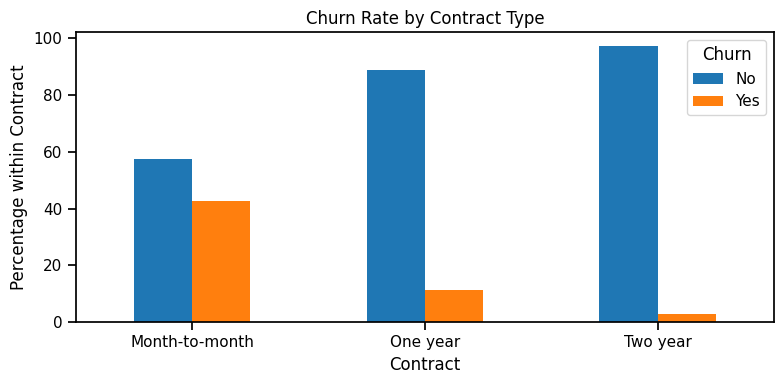

Contract type with highest churn rate: Month-to-month


In [10]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
display(contract_churn.round(2))

contract_churn.plot(kind="bar", figsize=(8,4))
plt.title("Churn Rate by Contract Type")
plt.ylabel("Percentage within Contract")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

highest_contract = contract_churn["Yes"].idxmax()
print("Contract type with highest churn rate:", highest_contract)

,Churn Rate %
tenure_bucket_eda,
0-12,47.44
13-24,28.71
25-48,20.39
49-72,9.51


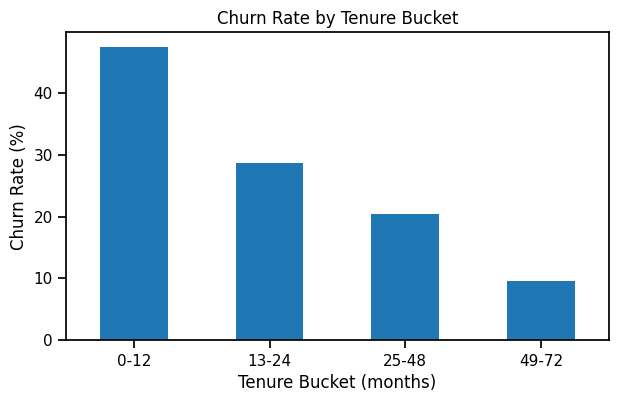

In [11]:
df["tenure_bucket_eda"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"]
)

tenure_churn_rate = (
    df.groupby("tenure_bucket_eda", observed=False)["Churn"]
      .apply(lambda s: (s == "Yes").mean() * 100)
)

display(tenure_churn_rate.round(2).to_frame("Churn Rate %"))

plt.figure(figsize=(7,4))
tenure_churn_rate.plot(kind="bar")
plt.title("Churn Rate by Tenure Bucket")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Tenure Bucket (months)")
plt.xticks(rotation=0)
plt.show()

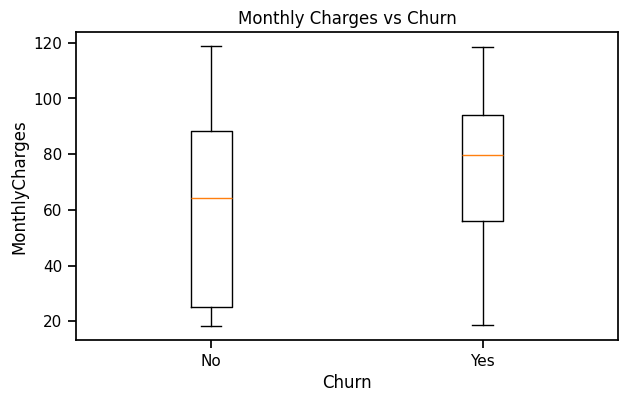

,Average MonthlyCharges
Churn,
No,61.27
Yes,74.44


Do churners pay more per month? Yes


In [12]:
groups = [
    df.loc[df["Churn"] == "No", "MonthlyCharges"],
    df.loc[df["Churn"] == "Yes", "MonthlyCharges"]
]
plt.figure(figsize=(7,4))
plt.boxplot(groups, tick_labels=["No", "Yes"])
plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("MonthlyCharges")
plt.show()

monthly_by_churn = df.groupby("Churn")["MonthlyCharges"].mean().round(2)
display(monthly_by_churn.to_frame("Average MonthlyCharges"))
print("Do churners pay more per month?",
      "Yes" if monthly_by_churn.get("Yes", 0) > monthly_by_churn.get("No", 0) else "No")

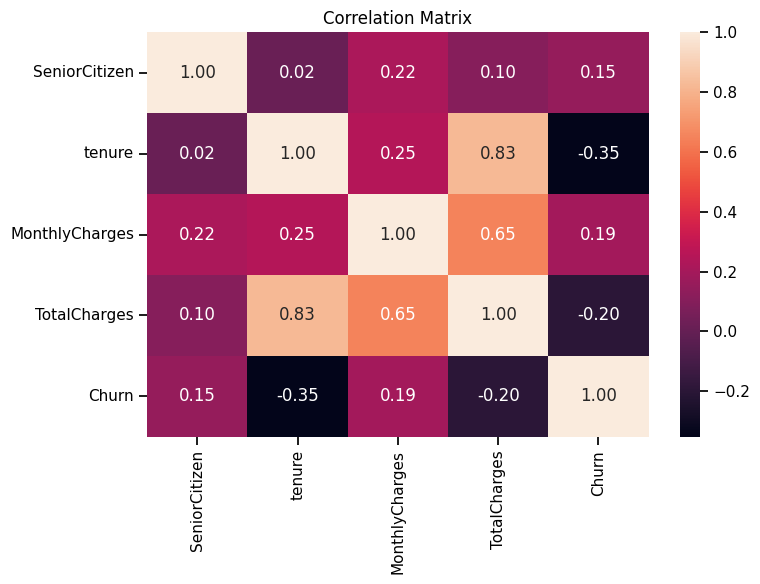

Strongest absolute correlations with Churn:


,Abs Correlation
tenure,0.352229
TotalCharges,0.199037
MonthlyCharges,0.193356
SeniorCitizen,0.150889


In [13]:
corr_df = df.select_dtypes(include=np.number).copy()
corr_df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

plt.figure(figsize=(8,6))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

print("Strongest absolute correlations with Churn:")
display(corr_df.corr()["Churn"].drop("Churn").abs().sort_values(ascending=False).to_frame("Abs Correlation"))

In [14]:
risk_summary = (
    df.assign(
        low_tenure=df["tenure"] <= 12,
        high_monthly=df["MonthlyCharges"] >= df["MonthlyCharges"].median()
    )
    .groupby(["Contract", "low_tenure", "high_monthly"])["Churn"]
    .apply(lambda s: (s == "Yes").mean() * 100)
    .sort_values(ascending=False)
    .head(10)
)

print("Highest-risk combinations (% churn):")
display(risk_summary.to_frame("Churn Rate %").round(2))

Highest-risk combinations (% churn):


Churn Rate %
Contract       low_tenure high_monthly              
Month-to-month True       True                 69.73
               False      True                 41.44
               True       False                38.62
One year       True       True                 23.08
Month-to-month False      False                18.52
One year       False      True                 17.10
               True       False                 9.01
               False      False                 5.21
Two year       False      True                  4.73
                          False                 1.39

**EDA interpretation:**  
The analysis checks whether customers on **Month-to-month contracts**, with **short tenure** and relatively **high MonthlyCharges**, form the highest-risk churn segment. The exact percentages printed above should be used as evidence in your viva/exam explanation.

## 🔧 Step 3: Data Preprocessing & Feature Engineering

### 3.1 Drop & Clean

In [15]:
model_df = df.drop(columns=["tenure_bucket_eda"]).copy()

model_df = model_df.drop(columns=["customerID"])

print("Missing values:")
display(model_df.isna().sum().sort_values(ascending=False).head())

Missing values:


gender            0
SeniorCitizen     0
TotalCharges      0
MonthlyCharges    0
PaymentMethod     0
dtype: int64

### 3.2 Feature Engineering

In [16]:
model_df["tenure_group"] = pd.cut(
    model_df["tenure"],
    bins=[-1, 12, 36, 60, np.inf],
    labels=["New", "Mid", "Senior", "Loyal"]
)

service_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]
model_df["num_services"] = (model_df[service_cols] == "Yes").sum(axis=1)

model_df["AutoPay"] = (
    model_df["PaymentMethod"].str.contains("automatic", case=False, na=False)
).astype(int)

display(model_df[["tenure", "tenure_group", "num_services", "PaymentMethod", "AutoPay"]].head(10))

,tenure,tenure_group,num_services,PaymentMethod,AutoPay
0,1,New,1,Electronic check,0
1,34,Mid,2,Mailed check,0
2,2,New,2,Mailed check,0
3,45,Senior,3,Bank transfer (automatic),1
4,2,New,0,Electronic check,0
5,8,New,3,Electronic check,0
6,22,Mid,2,Credit card (automatic),1
7,10,New,1,Mailed check,0
8,28,Mid,4,Electronic check,0
9,62,Loyal,2,Bank transfer (automatic),1


### 3.3 Encoding

In [17]:
y = model_df["Churn"].map({"No": 0, "Yes": 1}).astype(int)
X_raw = model_df.drop(columns=["Churn"]).copy()

tenure_order = {"New": 0, "Mid": 1, "Senior": 2, "Loyal": 3}
X_raw["tenure_group"] = X_raw["tenure_group"].map(tenure_order).astype(int)

binary_cols = []
for col in X_raw.select_dtypes(include="object").columns:
    vals = set(X_raw[col].dropna().unique())
    if vals.issubset({"Yes", "No"}):
        binary_cols.append(col)

for col in binary_cols:
    X_raw[col] = X_raw[col].map({"No": 0, "Yes": 1})

if "gender" in X_raw.columns:
    X_raw["gender"] = X_raw["gender"].map({"Female": 0, "Male": 1})

remaining_cat = X_raw.select_dtypes(include="object").columns.tolist()
X = pd.get_dummies(X_raw, columns=remaining_cat, drop_first=False, dtype=int)

print("Binary mapped columns:", binary_cols)
print("One-hot encoded columns:", remaining_cat)
print("Final encoded shape:", X.shape)
display(X.head())

Binary mapped columns: ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
One-hot encoded columns: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
Final encoded shape: (7043, 43)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,tenure_group,num_services,AutoPay,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,1,0,0,1,0,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,1,2,0,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,0,2,0,1,0,0,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,2,3,1,0,1,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,0,1,0,1,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,0,0,0,1,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0


### 3.4 Train-Test Split & Scaling


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 43)
X_test : (1409, 43)
y_train: (5634,)
y_test : (1409,)


In [19]:
scale_cols = ["tenure", "MonthlyCharges", "TotalCharges", "num_services"]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

display(X_train_scaled[scale_cols].head())

,tenure,MonthlyCharges,TotalCharges,num_services
3738,0.102371,-0.521976,-0.263289,0.507935
3151,-0.711743,0.337478,-0.504814,-0.570530
4860,-0.793155,-0.809013,-0.751213,0.507935
3867,-0.263980,0.284384,-0.173699,1.047168
3810,-1.281624,-0.676279,-0.990851,-1.109762


### 3.5 Handle Class Imbalance with SMOTE

In [20]:
print("Training class counts BEFORE SMOTE:")
display(y_train.value_counts().sort_index().rename(index={0:"No Churn", 1:"Churn"}).to_frame("Count"))

smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("\nTraining class counts AFTER SMOTE:")
display(pd.Series(y_train_smote).value_counts().sort_index().rename(index={0:"No Churn", 1:"Churn"}).to_frame("Count"))

print("\nTest set remains untouched:", X_test_scaled.shape)

Training class counts BEFORE SMOTE:


,Count
Churn,
No Churn,4139
Churn,1495



Training class counts AFTER SMOTE:


,Count
Churn,
No Churn,4139
Churn,4139



Test set remains untouched: (1409, 43)


## 🤖 Step 4: Model Building — KNN & Naive Bayes

In [21]:
results = {}
roc_data = {}
trained_models = {}

def evaluate_model(name, model, X_eval, y_eval, train_time=np.nan):
    pred = model.predict(X_eval)
    if hasattr(model, "predict_proba"):
        score = model.predict_proba(X_eval)[:, 1]
    else:
        score = model.decision_function(X_eval)

    metrics = {
        "Accuracy": accuracy_score(y_eval, pred),
        "Precision": precision_score(y_eval, pred, zero_division=0),
        "Recall": recall_score(y_eval, pred, zero_division=0),
        "F1": f1_score(y_eval, pred, zero_division=0),
        "AUC_ROC": roc_auc_score(y_eval, score),
        "Training_Time_s": train_time
    }
    results[name] = metrics
    trained_models[name] = model
    fpr, tpr, _ = roc_curve(y_eval, score)
    roc_data[name] = (fpr, tpr, metrics["AUC_ROC"])

    print(name)
    print(pd.Series(metrics).round(4))
    print("\nClassification Report:")
    print(classification_report(y_eval, pred, target_names=["No Churn", "Churn"], zero_division=0))
    return pred, score

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=["No Churn","Churn"],
                yticklabels=["No Churn","Churn"])
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

### 4.1 K-Nearest Neighbours (KNN)

In [22]:
knn_base = KNeighborsClassifier(n_neighbors=5)
start = time.perf_counter()
knn_base.fit(X_train_smote, y_train_smote)
knn_time = time.perf_counter() - start

knn_base_pred, knn_base_score = evaluate_model(
    "KNN_k5_Baseline", knn_base, X_test_scaled, y_test, knn_time
)

KNN_k5_Baseline
Accuracy           0.7360
Precision          0.5020
Recall             0.6818
F1                 0.5782
AUC_ROC            0.7921
Training_Time_s    0.0051
dtype: float64

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.87      0.76      0.81      1035
       Churn       0.50      0.68      0.58       374

    accuracy                           0.74      1409
   macro avg       0.68      0.72      0.69      1409
weighted avg       0.77      0.74      0.75      1409



Best k: 15


,k,Validation F1
0,1,0.5080
1,3,0.5617
2,5,0.5759
3,7,0.5730
4,9,0.5900
5,11,0.6062
6,15,0.6074


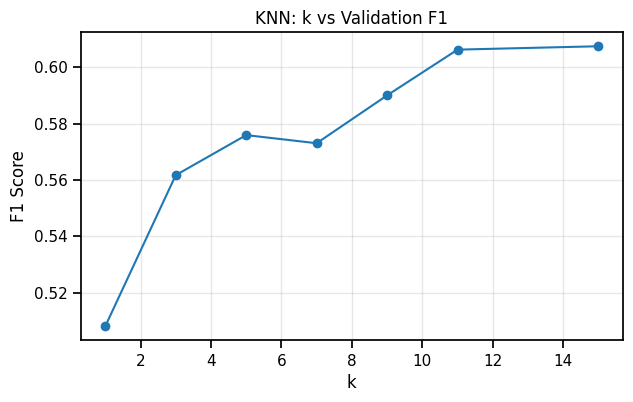

In [23]:
X_subtrain, X_val, y_subtrain, y_val = train_test_split(
    X_train_scaled, y_train,
    test_size=0.20, stratify=y_train, random_state=RANDOM_STATE
)

smote_tune = SMOTE(random_state=RANDOM_STATE)
X_sub_sm, y_sub_sm = smote_tune.fit_resample(X_subtrain, y_subtrain)

k_values = [1, 3, 5, 7, 9, 11, 15]
k_f1 = []

for k in k_values:
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_sub_sm, y_sub_sm)
    k_f1.append(f1_score(y_val, m.predict(X_val)))

best_k = k_values[int(np.argmax(k_f1))]
print("Best k:", best_k)
display(pd.DataFrame({"k": k_values, "Validation F1": k_f1}).round(4))

plt.figure(figsize=(7,4))
plt.plot(k_values, k_f1, marker="o")
plt.title("KNN: k vs Validation F1")
plt.xlabel("k")
plt.ylabel("F1 Score")
plt.grid(alpha=0.3)
plt.show()

KNN
Accuracy           0.7218
Precision          0.4849
Recall             0.7727
F1                 0.5959
AUC_ROC            0.8120
Training_Time_s    0.0046
dtype: float64

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.70      0.79      1035
       Churn       0.48      0.77      0.60       374

    accuracy                           0.72      1409
   macro avg       0.69      0.74      0.69      1409
weighted avg       0.79      0.72      0.74      1409



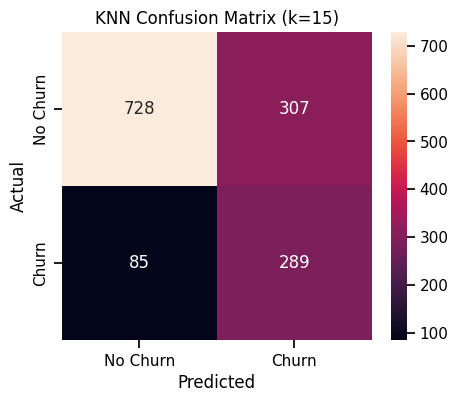

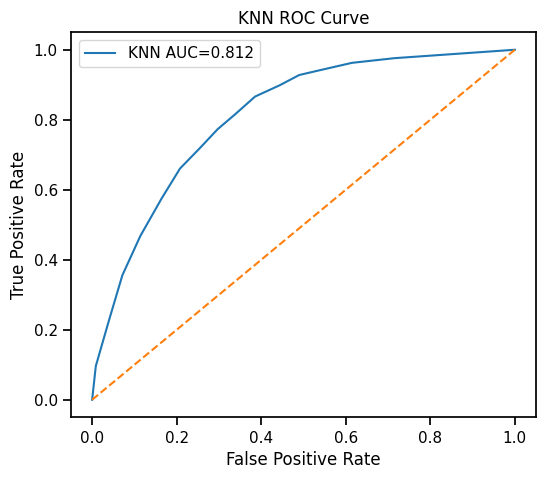

In [24]:
knn = KNeighborsClassifier(n_neighbors=best_k)
start = time.perf_counter()
knn.fit(X_train_smote, y_train_smote)
knn_time = time.perf_counter() - start

knn_pred, knn_score = evaluate_model("KNN", knn, X_test_scaled, y_test, knn_time)
plot_cm(y_test, knn_pred, f"KNN Confusion Matrix (k={best_k})")

fpr, tpr, auc_val = roc_data["KNN"]
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"KNN AUC={auc_val:.3f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN ROC Curve")
plt.legend()
plt.show()

### 4.2 Naive Bayes — GaussianNB

GaussianNB
Accuracy           0.6998
Precision          0.4630
Recall             0.8209
F1                 0.5921
AUC_ROC            0.8099
Training_Time_s    0.0059
dtype: float64

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.91      0.66      0.76      1035
       Churn       0.46      0.82      0.59       374

    accuracy                           0.70      1409
   macro avg       0.69      0.74      0.68      1409
weighted avg       0.79      0.70      0.72      1409

Learned class priors after SMOTE: [0.5 0.5]
Original training churn rate: 0.2654
Because GaussianNB was trained on balanced SMOTE data, its learned priors are expected to be close to 0.5/0.5 rather than the original churn rate.


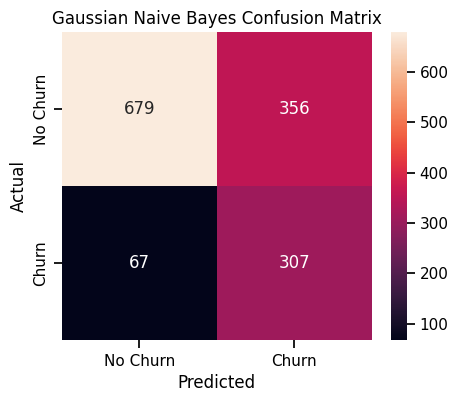

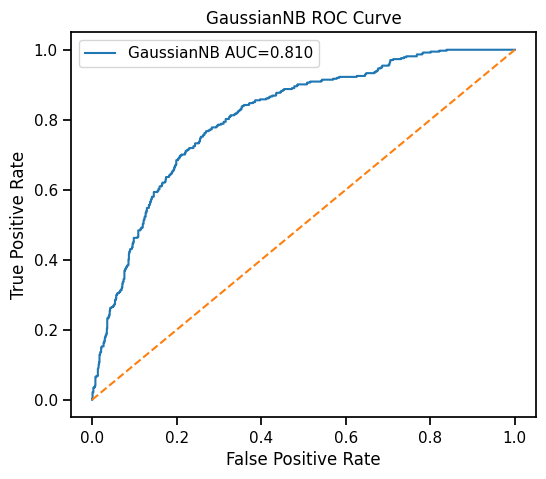

In [25]:
nb = GaussianNB()
start = time.perf_counter()
nb.fit(X_train_smote, y_train_smote)
nb_time = time.perf_counter() - start

nb_pred, nb_score = evaluate_model("GaussianNB", nb, X_test_scaled, y_test, nb_time)

print("Learned class priors after SMOTE:", np.round(nb.class_prior_, 4))
print("Original training churn rate:", round(y_train.mean(), 4))
print("Because GaussianNB was trained on balanced SMOTE data, its learned priors are expected to be close to 0.5/0.5 rather than the original churn rate.")

plot_cm(y_test, nb_pred, "Gaussian Naive Bayes Confusion Matrix")

fpr, tpr, auc_val = roc_data["GaussianNB"]
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"GaussianNB AUC={auc_val:.3f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("GaussianNB ROC Curve")
plt.legend()
plt.show()

## 🧱 Step 5: Model Building — SVM & Decision Tree

### 5.1 Support Vector Machine (SVM)

SVM_C1_Baseline
Accuracy           0.7743
Precision          0.5619
Recall             0.6791
F1                 0.6150
AUC_ROC            0.8177
Training_Time_s    3.8924
dtype: float64

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.87      0.81      0.84      1035
       Churn       0.56      0.68      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.77      0.78      1409



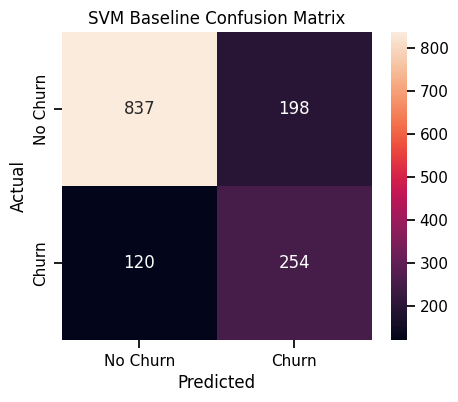

In [26]:
svm_base = SVC(
    kernel="rbf", C=1, gamma="scale",
    probability=True, random_state=RANDOM_STATE
)
start = time.perf_counter()
svm_base.fit(X_train_smote, y_train_smote)
svm_time = time.perf_counter() - start

svm_base_pred, svm_base_score = evaluate_model(
    "SVM_C1_Baseline", svm_base, X_test_scaled, y_test, svm_time
)
plot_cm(y_test, svm_base_pred, "SVM Baseline Confusion Matrix")

Best C: 10


,C,CV F1
0,0.1,0.7831
1,1.0,0.8018
2,10.0,0.8028
3,100.0,0.7977


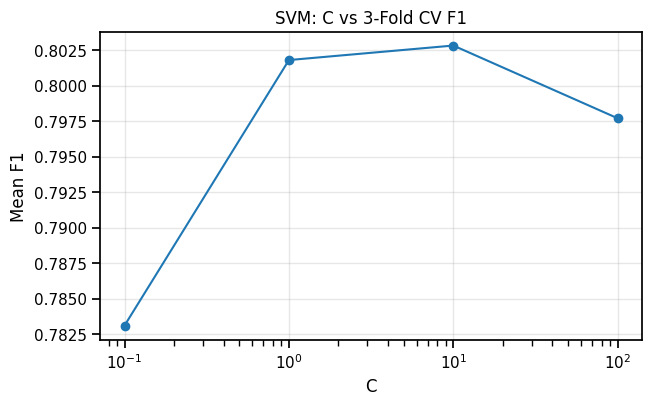

In [27]:
C_values = [0.1, 1, 10, 100]
svm_cv_f1 = []

for c in C_values:
    m = SVC(kernel="rbf", C=c, gamma="scale")
    scores = cross_val_score(m, X_train_smote, y_train_smote, cv=3, scoring="f1", n_jobs=-1)
    svm_cv_f1.append(scores.mean())

best_C = C_values[int(np.argmax(svm_cv_f1))]
print("Best C:", best_C)
display(pd.DataFrame({"C": C_values, "CV F1": svm_cv_f1}).round(4))

plt.figure(figsize=(7,4))
plt.semilogx(C_values, svm_cv_f1, marker="o")
plt.title("SVM: C vs 3-Fold CV F1")
plt.xlabel("C")
plt.ylabel("Mean F1")
plt.grid(alpha=0.3)
plt.show()

SVM
Accuracy           0.7658
Precision          0.5495
Recall             0.6524
F1                 0.5966
AUC_ROC            0.8014
Training_Time_s    4.1757
dtype: float64

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.87      0.81      0.83      1035
       Churn       0.55      0.65      0.60       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.77      1409



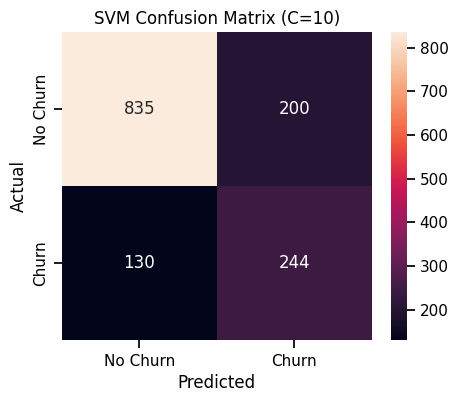

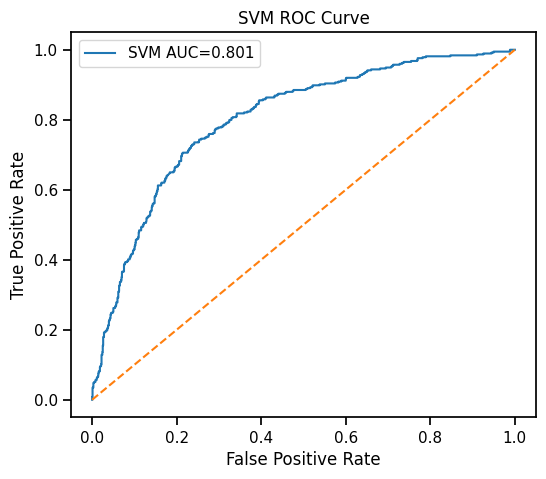

In [28]:
svm = SVC(
    kernel="rbf", C=best_C, gamma="scale",
    probability=True, random_state=RANDOM_STATE
)
start = time.perf_counter()
svm.fit(X_train_smote, y_train_smote)
svm_time = time.perf_counter() - start

svm_pred, svm_score = evaluate_model("SVM", svm, X_test_scaled, y_test, svm_time)
plot_cm(y_test, svm_pred, f"SVM Confusion Matrix (C={best_C})")

fpr, tpr, auc_val = roc_data["SVM"]
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"SVM AUC={auc_val:.3f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend()
plt.show()

### 5.2 Decision Tree Classifier

DecisionTree_depth5_Baseline
Accuracy           0.7544
Precision          0.5260
Recall             0.7567
F1                 0.6206
AUC_ROC            0.8324
Training_Time_s    0.0245
dtype: float64

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.75      0.82      1035
       Churn       0.53      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.77      1409



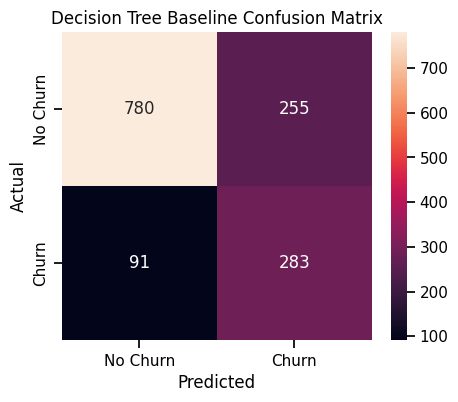

In [29]:
tree_base = DecisionTreeClassifier(
    max_depth=5, class_weight="balanced",
    random_state=RANDOM_STATE
)
start = time.perf_counter()
tree_base.fit(X_train_scaled, y_train)
tree_time = time.perf_counter() - start

tree_base_pred, tree_base_score = evaluate_model(
    "DecisionTree_depth5_Baseline", tree_base, X_test_scaled, y_test, tree_time
)
plot_cm(y_test, tree_base_pred, "Decision Tree Baseline Confusion Matrix")

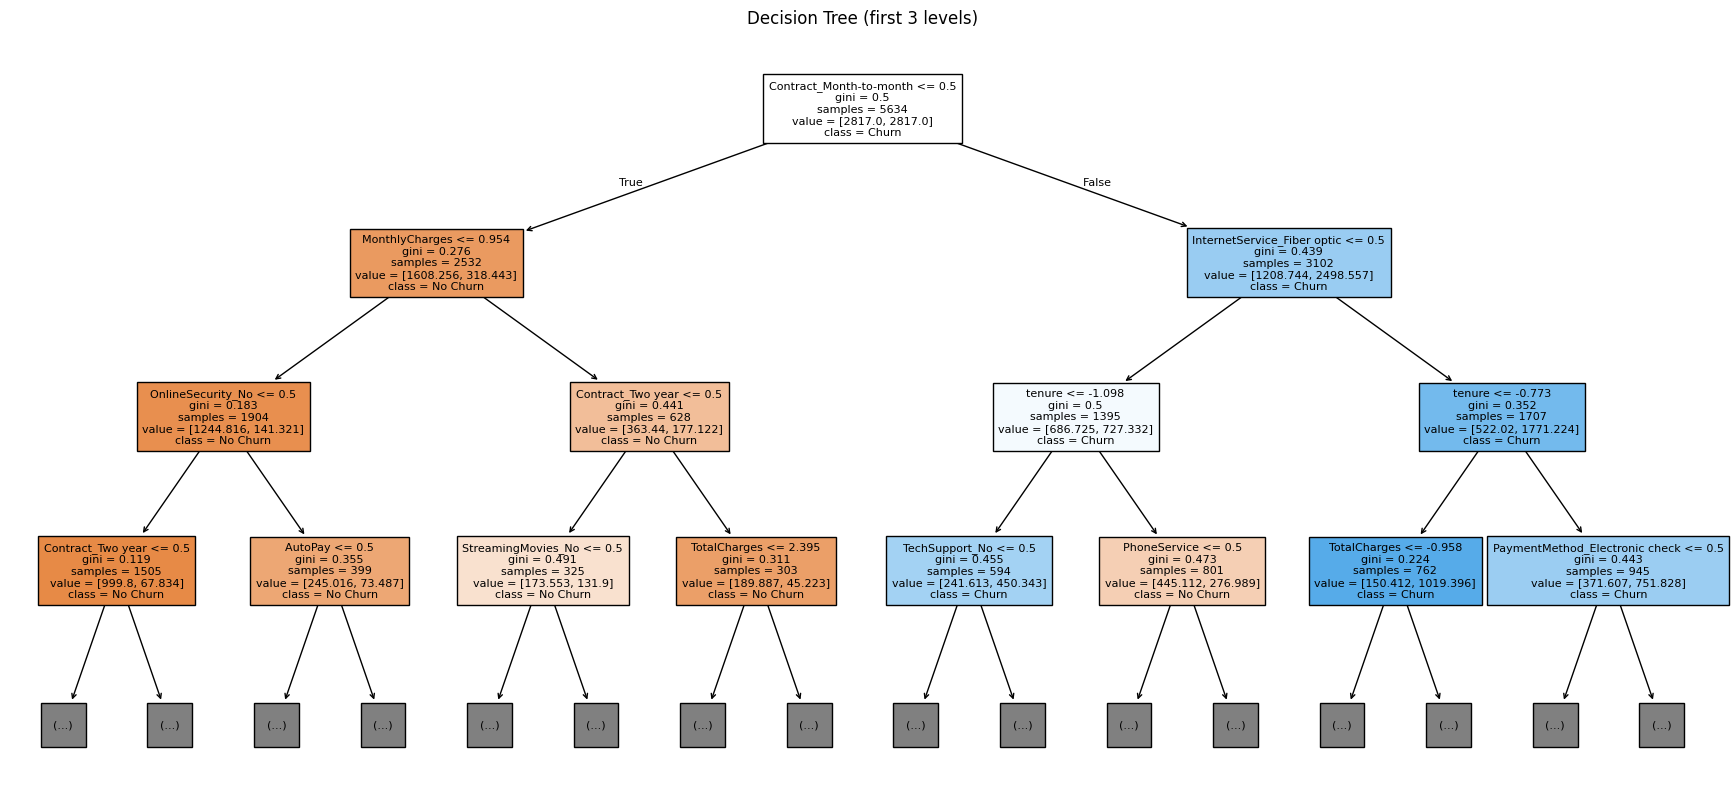

Root split feature: Contract_Month-to-month


In [30]:
plt.figure(figsize=(22,10))
plot_tree(
    tree_base,
    feature_names=X_train_scaled.columns,
    class_names=["No Churn","Churn"],
    filled=True,
    max_depth=3,
    fontsize=8
)
plt.title("Decision Tree (first 3 levels)")
plt.show()

root_feature = X_train_scaled.columns[tree_base.tree_.feature[0]]
print("Root split feature:", root_feature)

Best depth: 3


,max_depth,CV F1
0,3,0.6206
1,4,0.6037
2,5,0.6195
3,6,0.6101
4,7,0.5985
5,8,0.5809
6,None,0.4935


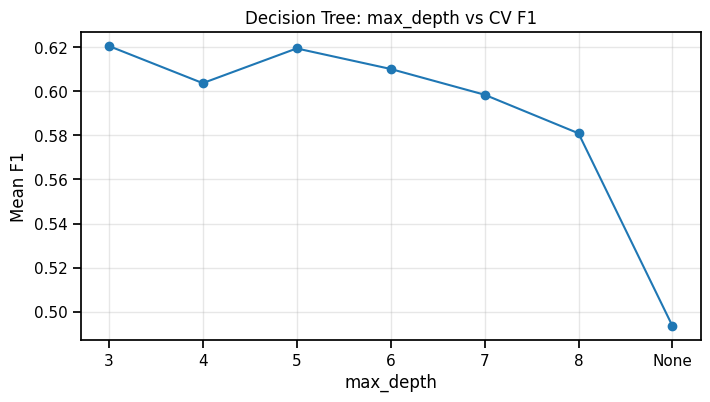

In [31]:
depth_values = [3, 4, 5, 6, 7, 8, None]
tree_cv_f1 = []

for depth in depth_values:
    m = DecisionTreeClassifier(
        max_depth=depth,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )
    scores = cross_val_score(m, X_train_scaled, y_train, cv=3, scoring="f1", n_jobs=-1)
    tree_cv_f1.append(scores.mean())

best_depth = depth_values[int(np.argmax(tree_cv_f1))]
print("Best depth:", best_depth)
display(pd.DataFrame({"max_depth": [str(x) for x in depth_values], "CV F1": tree_cv_f1}).round(4))

plt.figure(figsize=(8,4))
plt.plot(range(len(depth_values)), tree_cv_f1, marker="o")
plt.xticks(range(len(depth_values)), [str(x) for x in depth_values])
plt.title("Decision Tree: max_depth vs CV F1")
plt.xlabel("max_depth")
plt.ylabel("Mean F1")
plt.grid(alpha=0.3)
plt.show()

DecisionTree
Accuracy           0.7459
Precision          0.5140
Recall             0.7834
F1                 0.6208
AUC_ROC            0.8144
Training_Time_s    0.0147
dtype: float64

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.75      0.76      1409



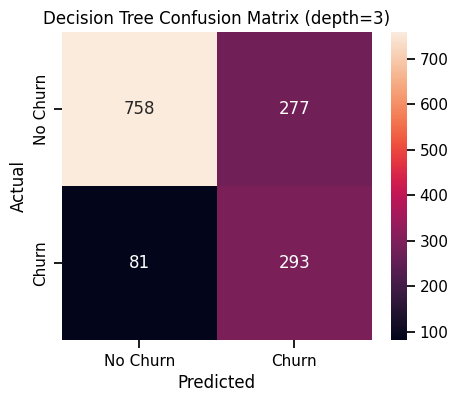

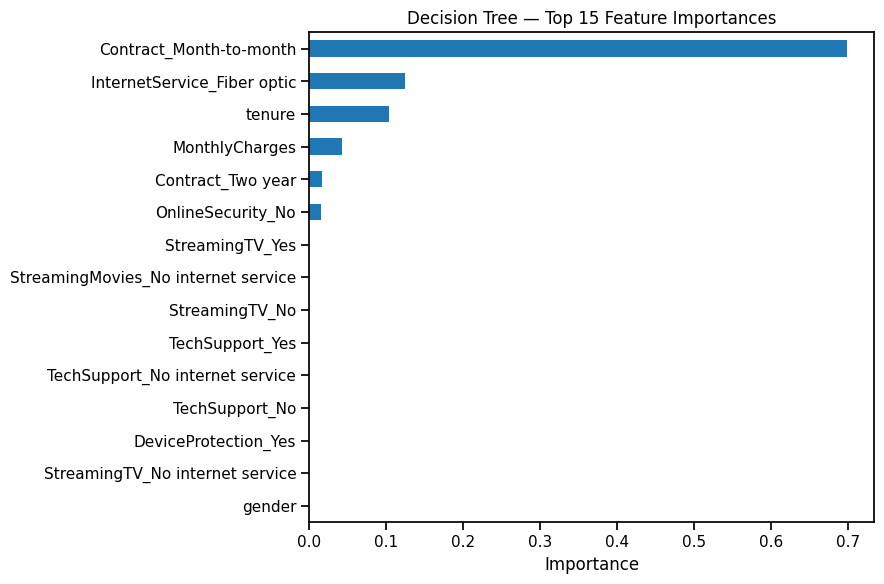

,Importance
Contract_Month-to-month,0.6991
InternetService_Fiber optic,0.1241
tenure,0.1037
MonthlyCharges,0.0422
Contract_Two year,0.0162
OnlineSecurity_No,0.0146
gender,0.0000
StreamingTV_No internet service,0.0000
DeviceProtection_Yes,0.0000
TechSupport_No,0.0000


In [32]:
tree = DecisionTreeClassifier(
    max_depth=best_depth,
    class_weight="balanced",
    random_state=RANDOM_STATE
)
start = time.perf_counter()
tree.fit(X_train_scaled, y_train)
tree_time = time.perf_counter() - start

tree_pred, tree_score = evaluate_model("DecisionTree", tree, X_test_scaled, y_test, tree_time)
plot_cm(y_test, tree_pred, f"Decision Tree Confusion Matrix (depth={best_depth})")

importance = pd.Series(tree.feature_importances_, index=X_train_scaled.columns)
top15 = importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(9,6))
top15.sort_values().plot(kind="barh")
plt.title("Decision Tree — Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

display(top15.to_frame("Importance").round(4))

### 5.3 class_weight='balanced' vs SMOTE

In [33]:
tree_smote = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE)
tree_smote.fit(X_train_smote, y_train_smote)
pred_smote = tree_smote.predict(X_test_scaled)

tree_weighted = DecisionTreeClassifier(
    max_depth=best_depth,
    class_weight="balanced",
    random_state=RANDOM_STATE
)
tree_weighted.fit(X_train_scaled, y_train)
pred_weighted = tree_weighted.predict(X_test_scaled)

comparison_imbalance = pd.DataFrame({
    "Approach": ["SMOTE", "class_weight='balanced'"],
    "Recall_Churn": [
        recall_score(y_test, pred_smote),
        recall_score(y_test, pred_weighted)
    ],
    "Precision_Churn": [
        precision_score(y_test, pred_smote),
        precision_score(y_test, pred_weighted)
    ],
    "F1_Churn": [
        f1_score(y_test, pred_smote),
        f1_score(y_test, pred_weighted)
    ]
}).sort_values("Recall_Churn", ascending=False)

display(comparison_imbalance.round(4))
print("Better Recall approach:", comparison_imbalance.iloc[0]["Approach"])

,Approach,Recall_Churn,Precision_Churn,F1_Churn
0,SMOTE,0.7834,0.514,0.6208
1,class_weight='balanced',0.7834,0.514,0.6208


Better Recall approach: SMOTE


## 📈 Step 6: Model Evaluation & Comparison

In [34]:
model_order = ["KNN", "GaussianNB", "SVM", "DecisionTree"]
comparison = pd.DataFrame({name: results[name] for name in model_order}).T
comparison = comparison.sort_values("Recall", ascending=False)

print("Model comparison sorted by Churn Recall:")
display(comparison.round(4))

Model comparison sorted by Churn Recall:


,Accuracy,Precision,Recall,F1,AUC_ROC,Training_Time_s
GaussianNB,0.6998,0.4630,0.8209,0.5921,0.8099,0.0059
DecisionTree,0.7459,0.5140,0.7834,0.6208,0.8144,0.0147
KNN,0.7218,0.4849,0.7727,0.5959,0.8120,0.0046
SVM,0.7658,0.5495,0.6524,0.5966,0.8014,4.1757


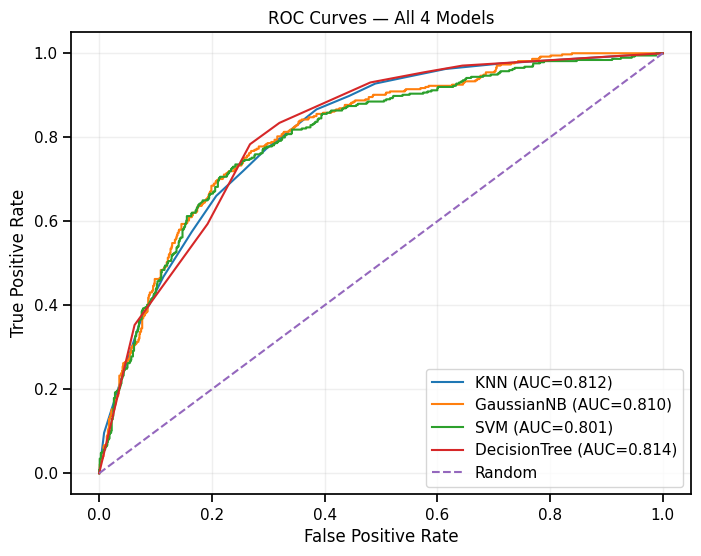

In [35]:
plt.figure(figsize=(8,6))
for name in model_order:
    fpr, tpr, auc_val = roc_data[name]
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")

plt.plot([0,1],[0,1],"--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All 4 Models")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

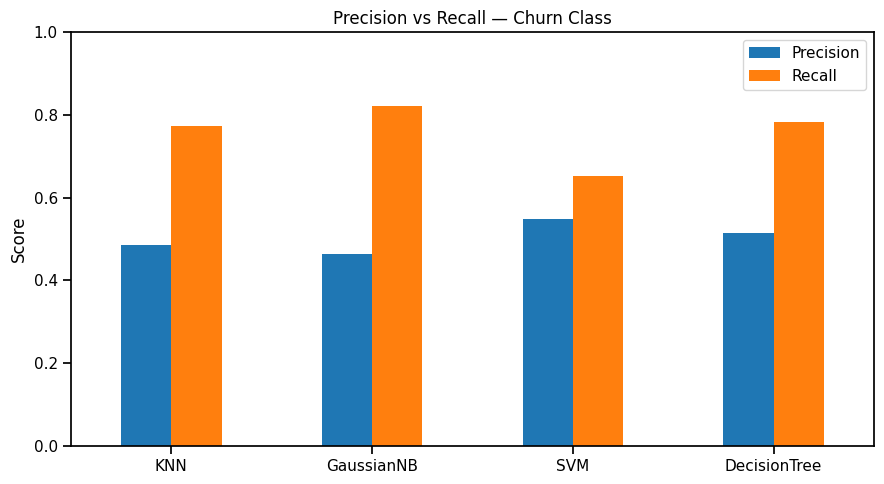

In [36]:
pr_df = comparison.loc[model_order, ["Precision", "Recall"]]
pr_df.plot(kind="bar", figsize=(9,5))
plt.title("Precision vs Recall — Churn Class")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
ranked = comparison.sort_values(["Recall", "F1", "AUC_ROC"], ascending=False)
best_model_name = ranked.index[0]
best_model = trained_models[best_model_name]

print("Recommended model by Recall-first ranking:", best_model_name)
display(ranked.round(4))

best_row = ranked.iloc[0]
print(
    f"Recommendation: Deploy {best_model_name} as the first candidate because it achieved "
    f"Recall={best_row['Recall']:.3f}, F1={best_row['F1']:.3f}, and AUC={best_row['AUC_ROC']:.3f} "
    "on the untouched test set. Recall is prioritized because False Negatives are costly in churn. "
    "Precision must still be monitored because the retention team has limited daily calling capacity. "
    "If two models have similar Recall, prefer the more interpretable and faster model for operational use. "
    "A final production decision should also validate performance on recent out-of-time customer data."
)

Recommended model by Recall-first ranking: GaussianNB


,Accuracy,Precision,Recall,F1,AUC_ROC,Training_Time_s
GaussianNB,0.6998,0.4630,0.8209,0.5921,0.8099,0.0059
DecisionTree,0.7459,0.5140,0.7834,0.6208,0.8144,0.0147
KNN,0.7218,0.4849,0.7727,0.5959,0.8120,0.0046
SVM,0.7658,0.5495,0.6524,0.5966,0.8014,4.1757


Recommendation: Deploy GaussianNB as the first candidate because it achieved Recall=0.821, F1=0.592, and AUC=0.810 on the untouched test set. Recall is prioritized because False Negatives are costly in churn. Precision must still be monitored because the retention team has limited daily calling capacity. If two models have similar Recall, prefer the more interpretable and faster model for operational use. A final production decision should also validate performance on recent out-of-time customer data.


## 🔍 Step 7: Error Analysis & Interpretation

### 7.1 Error Analysis on Best Model

In [38]:
best_pred = best_model.predict(X_test_scaled)
test_profile = model_df.loc[X_test.index].copy()
test_profile["ActualChurn"] = y_test
test_profile["PredictedChurn"] = best_pred

false_negatives = test_profile[
    (test_profile["ActualChurn"] == 1) &
    (test_profile["PredictedChurn"] == 0)
]

all_churners_test = test_profile[test_profile["ActualChurn"] == 1]

print("False Negatives:", len(false_negatives))
print("\nFalse Negative profile:")
fn_profile = {
    "Average tenure": false_negatives["tenure"].mean(),
    "Average MonthlyCharges": false_negatives["MonthlyCharges"].mean(),
    "Most common Contract": false_negatives["Contract"].mode().iloc[0] if len(false_negatives) else "N/A"
}
display(pd.Series(fn_profile).to_frame("False Negatives"))

print("\nOverall test churner profile:")
churn_profile = {
    "Average tenure": all_churners_test["tenure"].mean(),
    "Average MonthlyCharges": all_churners_test["MonthlyCharges"].mean(),
    "Most common Contract": all_churners_test["Contract"].mode().iloc[0] if len(all_churners_test) else "N/A"
}
display(pd.Series(churn_profile).to_frame("All Churners"))

False Negatives: 67

False Negative profile:


,False Negatives
Average tenure,32.552239
Average MonthlyCharges,62.153731
Most common Contract,Month-to-month



Overall test churner profile:


,All Churners
Average tenure,16.462567
Average MonthlyCharges,72.767112
Most common Contract,Month-to-month


In [39]:
profile_compare = pd.DataFrame({
    "False Negatives": [
        false_negatives["tenure"].mean(),
        false_negatives["MonthlyCharges"].mean()
    ],
    "All Churners": [
        all_churners_test["tenure"].mean(),
        all_churners_test["MonthlyCharges"].mean()
    ]
}, index=["Average tenure", "Average MonthlyCharges"])

display(profile_compare.round(2))

print("Interpretation:")
print(
    "Compare the table above to identify whether missed churners have longer tenure, "
    "lower/higher monthly charges, or a different contract mix than typical churners. "
    "These differences reveal where the model is weakest."
)

,False Negatives,All Churners
Average tenure,32.55,16.46
Average MonthlyCharges,62.15,72.77


Interpretation:
Compare the table above to identify whether missed churners have longer tenure, lower/higher monthly charges, or a different contract mix than typical churners. These differences reveal where the model is weakest.


### 7.2 Feature Importance / Decision Insight

In [40]:
top5 = pd.Series(
    tree.feature_importances_,
    index=X_train_scaled.columns
).sort_values(ascending=False).head(5)

print("Top 5 Decision Tree split features:")
display(top5.to_frame("Importance").round(4))

print("\nBusiness-friendly interpretation:")
for feature, imp in top5.items():
    clean = feature.replace("_", " ")
    print(f"- {clean}: contributes strongly to separating churners from non-churners (importance={imp:.3f}).")

Top 5 Decision Tree split features:


,Importance
Contract_Month-to-month,0.6991
InternetService_Fiber optic,0.1241
tenure,0.1037
MonthlyCharges,0.0422
Contract_Two year,0.0162



Business-friendly interpretation:
- Contract Month-to-month: contributes strongly to separating churners from non-churners (importance=0.699).
- InternetService Fiber optic: contributes strongly to separating churners from non-churners (importance=0.124).
- tenure: contributes strongly to separating churners from non-churners (importance=0.104).
- MonthlyCharges: contributes strongly to separating churners from non-churners (importance=0.042).
- Contract Two year: contributes strongly to separating churners from non-churners (importance=0.016).


## 🚀 Step 8: Pipeline, Deployment & GitHub Submission

### 8.1 Save the Final Model Bundle

In [41]:
bundle = {
    "model_name": best_model_name,
    "model": best_model,
    "scaler": scaler,
    "scale_cols": scale_cols,
    "feature_columns": X.columns.tolist(),
    "tenure_order": tenure_order,
    "binary_cols": binary_cols,
    "remaining_categorical_cols": remaining_cat,
    "metadata": {
        "target_mapping": {"No": 0, "Yes": 1},
        "random_state": RANDOM_STATE
    }
}

joblib.dump(bundle, "churn_model.pkl")
print("Saved: churn_model.pkl")

Saved: churn_model.pkl


In [42]:
loaded = joblib.load("churn_model.pkl")
loaded_model = loaded["model"]

sample_X = X_test_scaled.iloc[:5]
sample_prob = loaded_model.predict_proba(sample_X)[:, 1]
sample_label = loaded_model.predict(sample_X)

sample_output = pd.DataFrame({
    "Churn_Probability": sample_prob,
    "Predicted_Label": np.where(sample_label == 1, "Yes", "No")
}, index=sample_X.index)

display(sample_output)

,Churn_Probability,Predicted_Label
437,5.370280e-19,No
2280,9.999850e-01,Yes
2235,7.397451e-07,No
4460,9.999886e-01,Yes
3761,1.512101e-15,No


### 8.2 GitHub Submission Checklist

Create a repository named **`telco-churn-supervised-learning`** and include:

- `CustomerChurn_SupervisedLearning.ipynb` — fully executed notebook
- `churn_model.pkl` — saved model bundle
- `summary_report.md` — 400–500 word report
- `requirements.txt`
- `README.md` — project overview, dataset link, and run instructions

### 8.3 Summary Report Guidance

Your `summary_report.md` should cover:
1. Business problem and dataset summary.
2. Preprocessing and class-imbalance strategy.
3. Recommended model with metric evidence.
4. Top 3 churn signals and retention actions.
5. Next steps such as more recent data, probability-threshold tuning, real-time scoring API, and monitoring.

In [43]:
requirements = '''pandas
numpy
matplotlib
seaborn
scikit-learn
imbalanced-learn
joblib
jupyter
'''
with open("requirements.txt", "w") as f:
    f.write(requirements)

print("Created requirements.txt")

Created requirements.txt


## ✅ Final Takeaway

For telecom churn, **Recall for the churn class is the primary evaluation metric** because missing a true churner can cost future customer value. However, retention capacity is limited, so **Precision, F1, AUC, interpretability, and training/inference latency** should also influence the final deployment choice.